<a href="https://colab.research.google.com/github/alexgarcia7173/The-Fisrt/blob/main/Space_X_Falcon_9_First_Stage_Landing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Librerias**

In [1]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

**Funcion para matrix de confusion**

In [2]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

**Cargar el conjunto de datos**

In [3]:
import requests
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response1 = requests.get(URL1)
text1 = io.BytesIO(response1.content)
data = pd.read_csv(text1)

In [4]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [5]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = requests.get(URL2)
text2 = io.BytesIO(resp2.content)
X = pd.read_csv(text2)

In [6]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


**TASK 1**

Create a NumPy array from the column Class in data, by applying the method to_numpy() then assign it to the variable Y

In [7]:
# columna Class almecenada en y como un array de numpy
Y = data['Class'].to_numpy()
Y

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

**TASK 2**

Standardize the data in X then reassign it to the variable X using the transform provided below

In [8]:
x= data.drop(columns = ['Class'])

# variables numericas en x
numCols=x.select_dtypes(include = ['float64','int32','int64']).columns.tolist()

# Standarizar X
transform = preprocessing.StandardScaler()
# Pass the DataFrame subset containing only the numerical columns to fit_transform
x = transform.fit_transform(x[numCols])

**TASK 3**

Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to 0.2 and random_state to 2

In [9]:
# prompt: Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to 0.2 and random_state to 2

X_train, X_test, Y_train, Y_test = train_test_split(x, Y, test_size = 0.2, random_state = 2)


In [ ]:
Y_test.shape

(18,)

**TASK 4**

Create a **logistic regression** object

then create a GridSearchCV object logreg_cv with cv = 10.

Fit the object to find the best parameters from the dictionary parameters

In [10]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

lr=LogisticRegression()

logreg_cv = GridSearchCV(lr, parameters, cv = 10)

logreg_cv.fit(X_train, Y_train)


GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [11]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.7446428571428572


**TASK 5**

Calculate the accuracy on the test data using the method score

In [12]:
# accuracy on the test data using the method score:
print("accuracy :",logreg_cv.score(X_test, Y_test))


accuracy : 0.8333333333333334


Matrix de confusion

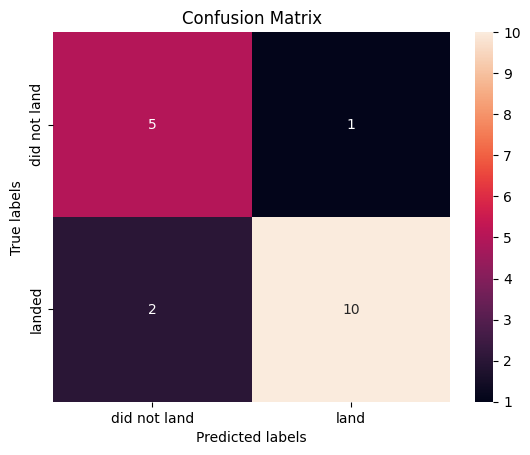

In [13]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

**TASK 6**

Create a support vector machine object

then create a GridSearchCV object svm_cv with cv = 10.

Fit the object to find the best parameters from the dictionary parameters.

In [14]:
# support vector machine object then create a GridSearchCV object svm_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

import numpy as np
parameters_svm = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv = 10)
svm_cv.fit(X_train, Y_train)

print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)


tuned hpyerparameters :(best parameters)  {'C': np.float64(1000.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8321428571428571


**TASK 7**

Calculate the accuracy on the test data using the method score

In [15]:
# accuracy on the test data using the method score:
print("accuracy :",svm_cv.score(X_test, Y_test))

accuracy : 0.7777777777777778


Matrix de confusion

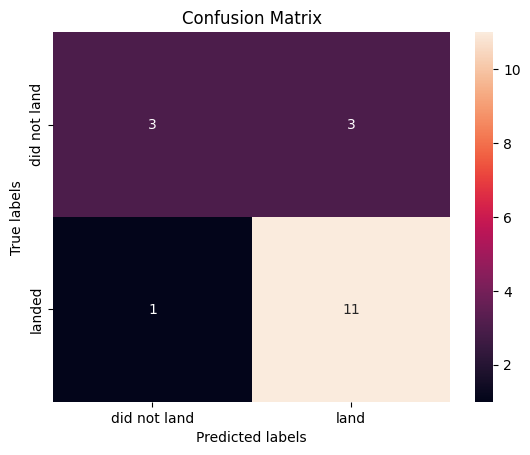

In [16]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

**TASK 8**

Create a decision tree classifier object
then create a GridSearchCV object tree_cv with cv = 10.

Fit the object to find the best parameters from the dictionary parameters.

In [17]:
# decision tree classifier object then create a GridSearchCV object tree_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

parameters_tree = {'criterion': ['gini', 'entropy'],
                     'splitter': ['best', 'random'],
                     'max_depth': [2*n for n in range(1,10)],
                     'max_features': ['sqrt'],
                     'min_samples_leaf': [1, 2, 4],
                     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv = 10)
tree_cv.fit(X_train, Y_train)

print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)


tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
accuracy : 0.8446428571428571


**TASK 9**

Calculate the accuracy of tree_cv on the test data using the method score

In [18]:
# accuracy on the test data using the method score:
print("accuracy :",tree_cv.score(X_test, Y_test))

accuracy : 0.8333333333333334


Matrix de confusion

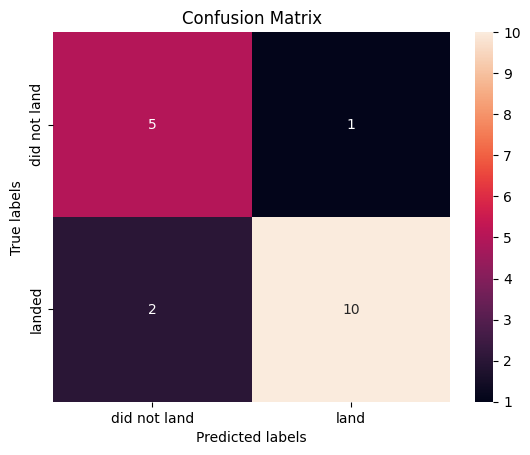

In [19]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

**TASK 10**

Create a k nearest neighbors object

then create a GridSearchCV object knn_cv with cv = 10.

Fit the object to find the best parameters from the dictionary parameters.

In [20]:
# k nearest neighbors object then create a GridSearchCV object knn_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters

parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv = 10)
knn_cv.fit(X_train, Y_train)

print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)


tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 3, 'p': 2}
accuracy : 0.7785714285714286


**TASK 11**

Calculate the accuracy of knn_cv on the test data using the method score

In [21]:
# accuracy on the test data using the method score:
print("accuracy :",knn_cv.score(X_test, Y_test))

accuracy : 0.7222222222222222


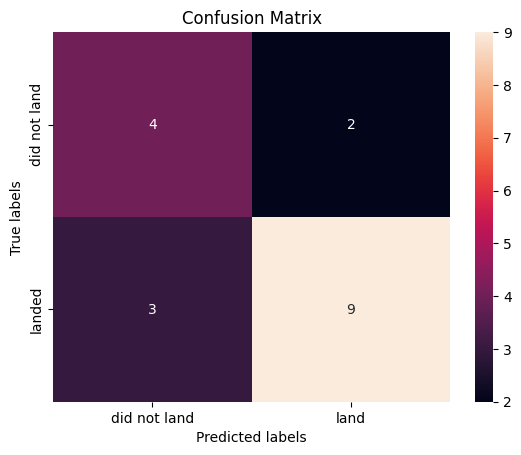

In [22]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

**TASK 12**

Find the method performs best

In [23]:
# prompt: Find the method performs best

from sklearn.metrics import accuracy_score

# Calculate accuracy scores for each model
logreg_accuracy = accuracy_score(Y_test, logreg_cv.predict(X_test))
svm_accuracy = accuracy_score(Y_test, svm_cv.predict(X_test))
tree_accuracy = accuracy_score(Y_test, tree_cv.predict(X_test))
knn_accuracy = accuracy_score(Y_test, knn_cv.predict(X_test))

# Create a dictionary to store the results
results = {
    'Logistic Regression': logreg_accuracy,
    'Support Vector Machine': svm_accuracy,
    'Decision Tree': tree_accuracy,
    'K-Nearest Neighbors': knn_accuracy
}

# Find the best-performing model
best_model = max(results, key=results.get)
best_accuracy = results[best_model]

print(f"Model Performance:")
for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

print(f"\nBest-performing model: {best_model} with accuracy: {best_accuracy:.4f}")


Model Performance:
Logistic Regression: 0.8333
Support Vector Machine: 0.7778
Decision Tree: 0.8333
K-Nearest Neighbors: 0.7222

Best-performing model: Logistic Regression with accuracy: 0.8333


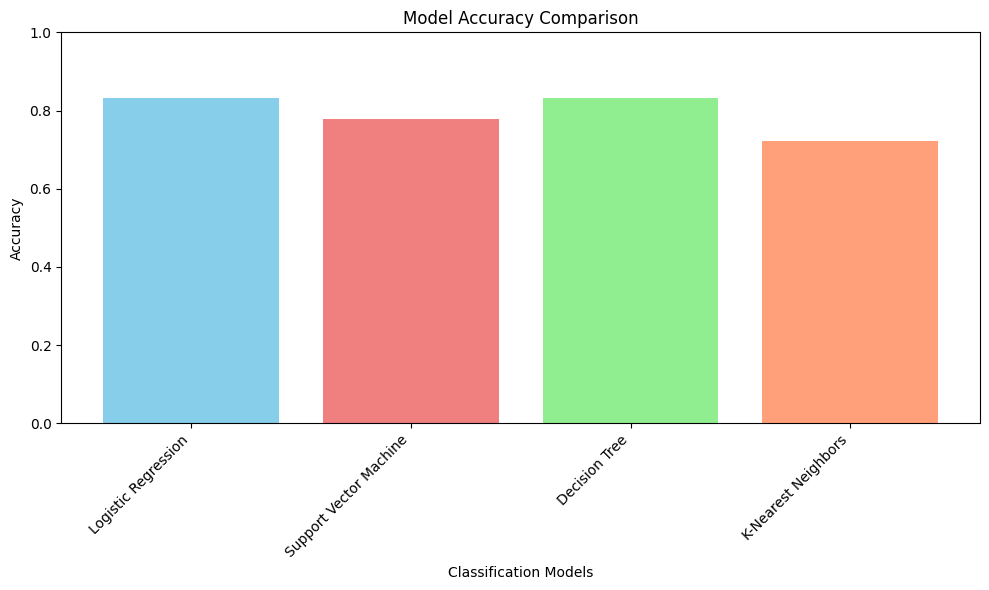

In [24]:
# prompt: VISUALIZE  THE MODEL ACCURACY FOR ALL BUILT CLASSIFICATION MODEL IN CHART BAR

import matplotlib.pyplot as plt

# Calculate accuracy scores for each model (assuming the previous code has run)
logreg_accuracy = accuracy_score(Y_test, logreg_cv.predict(X_test))
svm_accuracy = accuracy_score(Y_test, svm_cv.predict(X_test))
tree_accuracy = accuracy_score(Y_test, tree_cv.predict(X_test))
knn_accuracy = accuracy_score(Y_test, knn_cv.predict(X_test))


# Create a dictionary to store the results
results = {
    'Logistic Regression': logreg_accuracy,
    'Support Vector Machine': svm_accuracy,
    'Decision Tree': tree_accuracy,
    'K-Nearest Neighbors': knn_accuracy
}

# Model names and their accuracies
models = list(results.keys())
accuracies = list(results.values())

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon'])
plt.xlabel("Classification Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
